# 01. Graph-Based RAG (그래프 기반 RAG)

> 📌 **용어 주의**: 여기서 "Graph-Based"는 **LangGraph `StateGraph`로 RAG 파이프라인을 조립한다**는 뜻이에요. **지식 그래프(Knowledge Graph)와 Cypher 질의**로 관계형 질문을 처리하는 쪽은 **`11_Use_Cases/06-GraphRAG-Neo4j.ipynb`** 에 따로 있어요. 이 챕터(08)의 1~5 레슨은 모두 **벡터 기반 RAG**이고, 지식 그래프 기반은 11장의 use case로 연결돼요.

## 학습 목표

이 노트북을 마치면 다음을 할 수 있어요:

1. RAG(Retrieval-Augmented Generation)의 3가지 종류와 각 특징을 설명할 수 있어요
2. `StateGraph`로 Retrieve → Generate 2단계 RAG 파이프라인을 직접 구성할 수 있어요
3. `MemorySaver` 체크포인터와 `thread_id`로 멀티턴 대화 상태를 유지할 수 있어요
4. `add_conditional_edges`로 관련성 판단 기반 재검색 루프를 만들 수 있어요

## 사전 지식

- 이전 파트(Part 07)에서 배운 메모리 체크포인터(`MemorySaver`)와 `thread_id`
- `StateGraph`, `State`, `Node`, `Edge` 기초 (Part 02 참고)
- `MemorySaver`와 `thread_id`를 이용한 체크포인팅 (Part 02-06 참고)

## RAG란 무엇인가요?

**RAG(Retrieval-Augmented Generation)**는 LLM이 답변을 생성할 때 외부 지식 베이스에서 관련 문서를 먼저 검색하여 활용하는 기법이에요.
LLM의 학습 데이터 제한과 환각(Hallucination) 문제를 해결하는 핵심 패턴이에요.

> 🔑 **핵심 개념**: RAG는 **도서관 사서**와 같아요. 질문을 받으면 (1) 서가에서 관련 책을 찾고(Retrieve), (2) 그 책을 참고해서 답변을 작성해요(Generate). 사서가 책 없이 기억에만 의존하면 잘못된 정보를 줄 수 있듯이, LLM도 검색 없이 답변하면 환각(Hallucination)이 발생해요.

### 왜 RAG가 필요한가요?

LLM만으로 답변할 때 발생하는 문제를 정리해볼게요:

| 문제 | 증상 | RAG의 해결 방법 |
|------|------|----------------|
| **학습 데이터 한계** | 2024년 이후 정보를 모름 | 최신 문서를 검색해서 참고 |
| **환각(Hallucination)** | 그럴듯하지만 틀린 답변 | 실제 문서 근거로 답변 |
| **도메인 지식 부재** | 사내 문서 내용을 모름 | 사내 문서를 벡터화해서 검색 |
| **출처 불명** | "어디서 봤는데..." | 문서명 + 페이지 번호 명시 |

### RAG의 3가지 종류

| 종류 | 흐름 | 특징 | 적합한 경우 |
|------|------|------|------------|
| **Naive RAG** (2-Step) | 검색 → 생성 | 단순, 빠름 | 단순한 Q&A |
| **Agentic RAG** | 검색 → 판단 → 재검색 | 자율적 판단 | 복잡한 질문 |
| **Hybrid RAG** | 벡터 + 키워드 검색 | 높은 재현율 | 대규모 문서 |

이 노트북에서는 **Naive RAG(2-Step RAG)**와 **재검색 루프**를 LangGraph로 구현해요.

> 🔑 **핵심 개념**: RAG 파이프라인 5단계 - **Load(로드) → Split(분할) → Embed(임베딩) → Store(저장) → Retrieve+Generate(검색+생성)**. LangGraph는 마지막 Retrieve+Generate 단계를 노드로 분리하여 제어 흐름을 명시적으로 만들어줘요.

### 전체 아키텍처

```mermaid
flowchart TD
    User([사용자 질문<br/>User Question])
    Retrieve[retrieve<br/>문서 검색]
    LLMAnswer[llm_answer<br/>답변 생성]
    Relevance[relevance_check<br/>관련성 판단]
    Result([최종 답변<br/>Final Answer])

    User --> Retrieve
    Retrieve --> LLMAnswer
    LLMAnswer --> Result

    Retrieve2[retrieve<br/>재검색]
    Relevance2[relevance_check<br/>관련성 판단]

    User2([사용자 질문<br/>User Question]) --> Retrieve2
    Retrieve2 --> LLMAnswer2[llm_answer<br/>답변 생성]
    LLMAnswer2 --> Relevance2
    Relevance2 -- 관련성 낮음 --> Retrieve2
    Relevance2 -- 관련성 높음 --> Result2([최종 답변])

    classDef input fill:#d4edda,stroke:#28a745,color:#155724
    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef output fill:#fff3cd,stroke:#ffc107,color:#856404
    classDef decision fill:#e2d5f1,stroke:#6f42c1,color:#3d1f6e

    class User,User2 input
    class Retrieve,LLMAnswer,Retrieve2,LLMAnswer2 process
    class Relevance,Relevance2 decision
    class Result,Result2 output
```

> 🎯 **강의 포인트**: 왼쪽(Naive RAG)과 오른쪽(재검색 루프)의 차이를 강조해 주세요. 재검색 루프는 `add_conditional_edges`로 구현되며, 관련성이 낮으면 다시 검색을 수행해요. 이것이 "Agentic" RAG의 핵심이에요.

## 환경 설정

In [5]:
# 환경 변수 로드 (.env 파일에서 API 키를 가져와요)
from dotenv import load_dotenv

load_dotenv(override=True)
# 환경 변수 로드 완료

True

In [6]:
# LangSmith 추적 설정 (RAG 파이프라인 실행 흐름을 시각화할 수 있어요)
import os

# os.environ["LANGCHAIN_TRACING_V2"] = "true"
# os.environ["LANGCHAIN_PROJECT"] = "LangGraph-08-RAG"

# LangSmith 추적 설정 완료

## 1. PDF 문서 기반 Retriever 구성

RAG의 첫 단계는 문서를 벡터 저장소에 인덱싱하는 거예요.
PDF를 로드하고, 청크(Chunk)로 분할한 뒤, 임베딩 벡터로 변환하여 FAISS 저장소에 저장해요.

### PDF 파이프라인 구성

```mermaid
flowchart LR
    PDF([PDF 문서]) --> Loader[PyPDFLoader<br/>PDF 로드]
    Loader --> Splitter[RecursiveCharacterTextSplitter<br/>청크 분할]
    Splitter --> Embedder[OpenAIEmbeddings<br/>벡터 변환]
    Embedder --> Store[(FAISS<br/>벡터 저장소)]
    Store --> Retriever[Retriever<br/>유사도 검색]

    classDef input fill:#d4edda,stroke:#28a745,color:#155724
    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef storage fill:#e2d5f1,stroke:#6f42c1,color:#3d1f6e
    classDef output fill:#fff3cd,stroke:#ffc107,color:#856404

    class PDF input
    class Loader,Splitter,Embedder process
    class Store storage
    class Retriever output
```

> 🔑 **핵심 개념**: 벡터 검색은 **의미 기반 검색 엔진**이에요. 키워드가 정확히 일치하지 않아도 "투자금액"과 "자금 투입"처럼 의미가 비슷한 내용을 찾아줘요. 문장을 숫자 벡터(좌표)로 변환한 뒤, 가까운 좌표에 있는 문서를 "관련 문서"로 판단해요.

> 💡 **실무 팁**: `chunk_size=1000, chunk_overlap=200`은 검색 품질과 토큰 비용의 균형을 맞춘 설정이에요. 청크가 너무 작으면 맥락이 끊기고, 너무 크면 LLM 컨텍스트 윈도우를 낭비해요.

> ⚠️ **자주 하는 실수**: 임베딩 모델과 벡터 저장소를 매번 새로 만들면 비용이 많이 들어요. 실무에서는 `CacheBackedEmbeddings`로 임베딩 결과를 캐시하거나, 저장소를 디스크에 저장해두고 재사용해요.

**실습용 문서**: 소프트웨어정책연구소(SPRi) AI Brief 2023년 12월호 PDF
- `data/SPRI_AI_Brief_2023년12월호_F.pdf`

In [7]:
!uv add pypdf

Resolved 215 packages in 3ms
Checked 199 packages in 2ms


In [8]:
# ---------------------------------------------------
# PDF 로드 및 청크 분할
# ---------------------------------------------------
# PyPDFLoader: PDF 파일을 페이지 단위 Document로 변환해요
# RecursiveCharacterTextSplitter: 긴 문서를 적절한 크기로 잘라요
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

# PDF 로드: 각 페이지를 Document 객체로 만들어요
loader = PyPDFLoader("data/SPRI_AI_Brief_2023년12월호_F.pdf")
pages = loader.load()

print(f"PDF 로드 완료: {len(pages)}페이지")
print(f"첫 번째 페이지 미리보기: {pages[0].page_content[:100]}...")

PDF 로드 완료: 23페이지
첫 번째 페이지 미리보기: 2023년 12월호...


In [9]:
# ---------------------------------------------------
# 텍스트 분할 (청킹)
# ---------------------------------------------------
# chunk_size=1000: 각 청크의 최대 문자 수
# chunk_overlap=200: 이웃 청크와 겹치는 문자 수 (문맥 연속성 확보)
splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,     # 청크 크기: 1000자
    chunk_overlap=200,   # 오버랩: 200자 (맥락 연속성 유지)
)

# 문서를 청크로 분할해요
chunks = splitter.split_documents(pages)

print(f"분할 완료: {len(pages)}페이지 → {len(chunks)}개 청크")
print(f"\n첫 번째 청크 미리보기:")
print(f"  내용: {chunks[0].page_content[:150]}...")
print(f"  메타데이터: {chunks[0].metadata}")

분할 완료: 23페이지 → 60개 청크

첫 번째 청크 미리보기:
  내용: 2023년 12월호...
  메타데이터: {'producer': 'Hancom PDF 1.3.0.542', 'creator': 'Hwp 2018 10.0.0.13462', 'creationdate': '2023-12-08T13:28:38+09:00', 'author': 'dj', 'moddate': '2023-12-08T13:28:38+09:00', 'pdfversion': '1.4', 'source': 'data/SPRI_AI_Brief_2023년12월호_F.pdf', 'total_pages': 23, 'page': 0, 'page_label': '1'}


In [10]:
# ---------------------------------------------------
# 임베딩 + FAISS 벡터 저장소 구성
# ---------------------------------------------------
# OpenAIEmbeddings: 텍스트를 벡터(숫자 배열)로 변환해요
# FAISS: 고속 근사 최근접 이웃(ANN) 검색 라이브러리
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import FAISS

# 임베딩 모델 초기화 (text-embedding-3-small: 가성비 최고)
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

# FAISS 벡터 저장소 생성 (청크를 임베딩하여 저장해요)
# 벡터 저장소 생성 중 (API 호출 발생)...
vectorstore = FAISS.from_documents(chunks, embeddings)

# Retriever 생성: 질문과 유사한 청크를 찾아줘요
# k=4: 가장 유사한 문서 4개를 반환
pdf_retriever = vectorstore.as_retriever(search_kwargs={"k": 4})

print(f"벡터 저장소 생성 완료: {len(chunks)}개 벡터")
print(f"Retriever: 유사도 기반 상위 4개 문서 반환")

벡터 저장소 생성 완료: 60개 벡터
Retriever: 유사도 기반 상위 4개 문서 반환


### Retriever 테스트

실제로 질문을 넣어서 검색이 잘 되는지 확인해볼게요.

In [11]:
# 검색 테스트: 질문과 유사한 문서를 찾아요
test_query = "앤스로픽에 투자한 기업과 투자금액을 알려주세요."
search_results = pdf_retriever.invoke(test_query)

print(f"검색 질문: {test_query}")
print(f"검색 결과: {len(search_results)}개 문서 반환\n")

for i, doc in enumerate(search_results):
    print(f"[문서 {i+1}]")
    print(f"  출처: {doc.metadata.get('source', '알 수 없음')} (p.{doc.metadata.get('page', '?')+1})")
    print(f"  내용: {doc.page_content[:150]}...")
    print()

검색 질문: 앤스로픽에 투자한 기업과 투자금액을 알려주세요.
검색 결과: 4개 문서 반환

[문서 1]
  출처: data/SPRI_AI_Brief_2023년12월호_F.pdf (p.14)
  내용: 1. 정책/법제  2. 기업/산업 3. 기술/연구  4. 인력/교육구글, 앤스로픽에 20억 달러 투자로 생성 AI 협력 강화 n구글이 앤스로픽에 최대 20억 달러 투자에 합의하고 5억 달러를 우선 투자했으며, 앤스로픽은 구글과 클라우드 서비스 사용 계약도 체결n3대 클...

[문서 2]
  출처: data/SPRI_AI_Brief_2023년12월호_F.pdf (p.14)
  내용: £구글, 앤스로픽에 최대 20억 달러 투자 합의 및 클라우드 서비스 제공n구글이 2023년 10월 27일 앤스로픽에 최대 20억 달러를 투자하기로 합의했으며, 이 중 5억 달러를 우선 투자하고 향후 15억 달러를 추가로 투자할 방침∙구글은 2023년 2월 앤스로픽에 이...

[문서 3]
  출처: data/SPRI_AI_Brief_2023년12월호_F.pdf (p.10)
  내용: 1. 정책/법제  2. 기업/산업 3. 기술/연구  4. 인력/교육미국 프런티어 모델 포럼, 1,000만 달러 규모의 AI 안전 기금 조성n구글, 앤스로픽, 마이크로소프트, 오픈AI가 참여하는 프런티어 모델 포럼이 자선단체와 함께 AI 안전 연구를 위한 1,000만 달...

[문서 4]
  출처: data/SPRI_AI_Brief_2023년12월호_F.pdf (p.2)
  내용: Ⅰ. 인공지능 산업 동향 브리프 1. 정책/법제    ▹ 미국, 안전하고 신뢰할 수 있는 AI 개발과 사용에 관한 행정명령 발표  ·························1   ▹ G7, 히로시마 AI 프로세스를 통해 AI 기업 대상 국제 행동강령에 합의·····...



## 2. RAG 체인 구성

검색된 문서를 LLM 프롬프트에 담아 답변을 생성하는 체인을 만들어요.

> 🔑 **핵심 개념**: `format_docs` 함수는 `Document` 객체 리스트를 LLM이 읽을 수 있는 텍스트로 변환해요. XML 태그로 각 문서를 감싸면 LLM이 문서 경계를 명확히 이해해요 — **간접 프롬프트 인젝션 방어** 효과도 있어요.

> 💡 **실무 팁**: 컨텍스트를 `<document>` 태그로 묶으면 두 가지 이점이 있어요. 첫째, LLM이 "이 내용이 사용자 입력이 아닌 문서"임을 인지해요. 둘째, 프롬프트 인젝션 공격(악성 문서에 포함된 명령)을 방어해요.

In [12]:
# ---------------------------------------------------
# 헬퍼 함수: Document → 프롬프트용 텍스트 변환
# ---------------------------------------------------
# XML 태그로 문서를 감싸서 LLM이 경계를 명확히 인식하게 해요
# (간접 프롬프트 인젝션 방어 효과도 있어요)
from langchain_core.documents import Document
from typing import List


def format_docs(docs: List[Document]) -> str:
    """Document 리스트를 LLM 프롬프트용 텍스트로 변환해요.
    
    각 문서를 XML 태그로 감싸서 문서 경계를 명확히 표시해요.
    출처(source)와 페이지 번호도 포함해요.
    """
    formatted = []
    for doc in docs:
        # 출처 메타데이터 추출 (없으면 기본값 사용)
        source = doc.metadata.get("source", "알 수 없음")
        page = doc.metadata.get("page", 0)
        
        # XML 태그로 문서 내용, 출처, 페이지를 구조화
        formatted.append(
            f"<document>"
            f"<content>{doc.page_content}</content>"
            f"<source>{source}</source>"
            f"<page>{int(page) + 1}</page>"
            f"</document>"
        )
    return "\n".join(formatted)


# 테스트: 검색 결과를 포맷팅해요
formatted_context = format_docs(search_results)
# 포맷팅된 컨텍스트 미리보기:
print(formatted_context[:300])
# ...

<document><content>1. 정책/법제  2. 기업/산업 3. 기술/연구  4. 인력/교육구글, 앤스로픽에 20억 달러 투자로 생성 AI 협력 강화 n구글이 앤스로픽에 최대 20억 달러 투자에 합의하고 5억 달러를 우선 투자했으며, 앤스로픽은 구글과 클라우드 서비스 사용 계약도 체결n3대 클라우드 사업자인 구글, 마이크로소프트, 아마존은 차세대 AI 모델의 대표 기업인 앤스로픽 및 오픈AI와 협력을 확대하는 추세
KEY Contents</content><source>data/SPRI_AI_Brief_2023년12월호_F.


In [13]:
# ---------------------------------------------------
# RAG 체인 구성
# ---------------------------------------------------
# 프롬프트 → LLM → StrOutputParser 순서로 체인을 구성해요
from langchain.chat_models import init_chat_model
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

# 기본 모델: gpt-4o-mini (비용 효율, 학생 접근성)
# 다른 모델 옵션:
#   - "anthropic:claude-sonnet-4-5" (Anthropic)
#   - "ollama:llama3" (로컬)
llm = init_chat_model("openai:gpt-4o-mini")

# RAG 프롬프트 템플릿
# context: 검색된 문서 (format_docs로 포맷팅)
# question: 사용자 질문
# chat_history: 이전 대화 기록 (멀티턴 지원)
rag_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        """당신은 주어진 문서를 기반으로 질문에 정확하게 답변하는 AI 어시스턴트예요.

다음 규칙을 따르세요:
1. 제공된 문서(context)에 있는 내용만 사용하세요
2. 문서에 없는 내용은 "문서에서 찾을 수 없습니다"라고 말해요
3. 답변 끝에 출처 문서와 페이지를 명시하세요
4. 한국어로 답변하세요

참고 문서:
{context}"""
    ),
    ("placeholder", "{chat_history}"),
    ("human", "{question}"),
])

# LCEL 체인 구성: 프롬프트 → LLM → 문자열 파서
pdf_chain = rag_prompt | llm | StrOutputParser()

# RAG 체인 구성 완료
#   - 모델: gpt-4o-mini
#   - 프롬프트: context + chat_history + question

In [14]:
# 체인 단독 테스트 (그래프 없이 체인만 실행해볼게요)
test_answer = pdf_chain.invoke({
    "question": "앤스로픽에 투자한 기업과 투자금액을 알려주세요.",
    "context": formatted_context,
    "chat_history": [],  # 첫 질문이라 이전 대화 없음
})

# 체인 단독 테스트 결과:
print(test_answer)

앤스로픽에 투자한 기업과 투자금액은 다음과 같습니다:

1. 구글: 최대 20억 달러 (우선 투자 5억 달러 포함)
2. 아마존: 최대 40억 달러 계획
3. 마이크로소프트: 30억 달러 (추가로 100억 달러 투자 예정)

출처: data/SPRI_AI_Brief_2023년12월호_F.pdf, 페이지 14


## 3. State 정의

`State`는 그래프의 모든 노드가 공유하는 데이터 구조예요.
RAG 파이프라인에서는 질문, 검색된 문서, 생성된 답변, 대화 기록이 필요해요.

### State 설계 원칙

| 필드 | 타입 | Reducer | 설명 |
|------|------|---------|------|
| `question` | `str` | 덮어쓰기 | 현재 사용자 질문 |
| `context` | `str` | 덮어쓰기 | 검색된 문서 (포맷팅 후) |
| `answer` | `str` | 덮어쓰기 | 생성된 최종 답변 |
| `messages` | `list` | `add_messages` | 대화 히스토리 (누적) |

> 🔑 **핵심 개념**: `add_messages` 리듀서는 리스트를 **덮어쓰지 않고 누적**해요. 여러 노드에서 `messages`를 반환해도 모두 합쳐져요. 반면 `question`, `context`, `answer`는 마지막 값으로 덮어써요.

> 💡 **실무 팁**: State에는 **raw 데이터**를 저장하세요. 포맷팅(format_docs)은 노드 안에서 처리하는 것이 더 유연해요. State를 직렬화하기 쉽고, 여러 노드에서 다른 방식으로 포맷팅할 수 있어요.

In [15]:
# ---------------------------------------------------
# GraphState 정의 (TypedDict 기반)
# ---------------------------------------------------
# LangGraph v1에서는 TypedDict가 권장 방식이에요
# Annotated + add_messages로 누적 리듀서를 지정해요
from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages


class GraphState(TypedDict):
    """RAG 파이프라인의 그래프 상태 정의예요."""
    question: Annotated[str, "사용자 질문"]     # 현재 질문 (덮어쓰기)
    context: Annotated[str, "검색된 문서"]      # 포맷팅된 컨텍스트 (덮어쓰기)
    answer: Annotated[str, "생성된 답변"]        # 최종 답변 (덮어쓰기)
    messages: Annotated[list, add_messages]     # 대화 기록 (누적!)


# GraphState 정의 완료:
#   - question: str (덮어쓰기)
#   - context:  str (덮어쓰기)
#   - answer:   str (덮어쓰기)
#   - messages: list (add_messages - 누적!)

## 4. 노드(Node) 정의

RAG 파이프라인을 **검색 노드**와 **생성 노드**로 분리해요.
분리하면 각 노드를 독립적으로 테스트하고 교체할 수 있어요.

### 노드 책임 분리

```mermaid
flowchart LR
    Input([question]) --> Retrieve[retrieve_document<br>❶ 검색 담당]
    Retrieve --> ContextUpdate([context 업데이트])
    ContextUpdate --> LLMAnswer[llm_answer<br>❷ 생성 담당]
    LLMAnswer --> OutputUpdate([answer + messages 업데이트])

    classDef input fill:#d4edda,stroke:#28a745,color:#155724
    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef output fill:#fff3cd,stroke:#ffc107,color:#856404

    class Input,ContextUpdate,OutputUpdate input
    class Retrieve,LLMAnswer process
```

> 🎯 **강의 포인트**: 노드를 분리하는 이유를 설명해 주세요. 검색 노드를 웹 검색으로 교체하거나, 생성 노드의 모델을 변경할 때 다른 노드에 영향이 없어요. 이것이 "모듈식 설계"의 장점이에요.

In [16]:
# ---------------------------------------------------
# 노드 정의: 검색 노드 + 답변 생성 노드
# ---------------------------------------------------
# 각 노드는 GraphState를 입력받아 업데이트할 키를 딕셔너리로 반환해요

def retrieve_document(state: GraphState) -> GraphState:
    """문서를 검색하는 노드예요.
    
    사용자 질문으로 벡터 유사도 검색을 수행하고
    검색 결과를 XML 형태로 포맷팅해서 context에 저장해요.
    """
    # 상태에서 현재 질문을 가져와요
    question = state["question"]
    
    # 벡터 저장소에서 유사한 문서를 검색해요
    retrieved_docs = pdf_retriever.invoke(question)
    
    # Document 리스트를 XML 포맷 텍스트로 변환해요
    formatted_context = format_docs(retrieved_docs)
    
    # context 필드만 업데이트해서 반환해요
    return {"context": formatted_context}


def llm_answer(state: GraphState) -> GraphState:
    """답변을 생성하는 노드예요.
    
    검색된 문서(context)와 대화 기록(messages)을 활용하여
    LLM이 질문에 대한 답변을 생성해요.
    """
    # 상태에서 필요한 값을 가져와요
    question = state["question"]
    context = state["context"]
    
    # 대화 기록을 chat_history 형태로 변환해요
    # messages는 (role, content) 튜플 또는 Message 객체 리스트예요
    chat_history = state.get("messages", [])
    
    # RAG 체인 호출: context + chat_history + question → 답변 생성
    response = pdf_chain.invoke({
        "question": question,
        "context": context,
        "chat_history": chat_history,
    })
    
    # answer 업데이트 + messages에 이번 대화 추가 (add_messages로 누적)
    return {
        "answer": response,
        "messages": [
            ("user", question),       # 사용자 질문 기록
            ("assistant", response),  # AI 답변 기록
        ],
    }


# 노드 정의 완료:
#   - retrieve_document: 벡터 검색 → context 업데이트
#   - llm_answer: RAG 체인 실행 → answer + messages 업데이트

## 5. Naive RAG 그래프 구성

가장 단순한 RAG 파이프라인이에요: **START → retrieve → llm_answer → END**

MemorySaver 체크포인터를 추가하면 멀티턴 대화를 지원해요.

In [17]:
# ---------------------------------------------------
# Naive RAG 그래프 구성
# ---------------------------------------------------
# StateGraph: 상태 기반 그래프의 핵심 클래스예요
# MemorySaver: 메모리 내 체크포인터 (thread_id로 대화 구분)
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver

# 그래프 생성 (GraphState를 스키마로 사용)
workflow = StateGraph(GraphState)

# 노드 등록 (이름, 함수 순서)
workflow.add_node("retrieve", retrieve_document)   # 검색 노드
workflow.add_node("llm_answer", llm_answer)         # 답변 생성 노드

# 엣지 연결: 실행 순서를 정의해요
workflow.add_edge(START, "retrieve")      # 시작 → 검색
workflow.add_edge("retrieve", "llm_answer")  # 검색 → 답변 생성
workflow.add_edge("llm_answer", END)      # 답변 생성 → 종료

# 체크포인터 설정 (대화 기록 저장)
# MemorySaver: 프로세스 메모리에 저장 (재시작하면 초기화)
# 실무에서는 PostgresSaver, SqliteSaver 등 영구 저장소 사용
memory = MemorySaver()

# 그래프 컴파일 (실행 가능한 형태로 변환)
naive_rag = workflow.compile(checkpointer=memory)

# Naive RAG 그래프 컴파일 완료

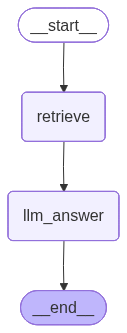

In [18]:
# 그래프 흐름: START → retrieve → llm_answer → END
# retrieve: 벡터 유사도 검색으로 관련 문서를 찾아 context에 저장해요
# llm_answer: context + chat_history + question으로 RAG 답변을 생성해요
# MemorySaver: thread_id별로 대화 히스토리를 유지해서 멀티턴 대화를 지원해요
from IPython.display import Image, display

display(Image(naive_rag.get_graph().draw_mermaid_png()))

## 6. 그래프 실행

**단일 질문 실행**부터 시작해서 **멀티턴 대화**까지 테스트해볼게요.

> ⚠️ **자주 하는 실수**: 같은 `thread_id`로 다시 실행하면 이전 대화가 이어져요. 새로운 대화를 시작하려면 새로운 `thread_id`를 사용하세요.

In [19]:
# ---------------------------------------------------
# 그래프 실행 (스트리밍 모드)
# ---------------------------------------------------
# thread_id: 대화 세션 구분자 (같은 ID면 이전 대화가 이어져요)
# recursion_limit: 재귀 최대 횟수 (무한 루프 방지)
import uuid
from langchain_core.runnables import RunnableConfig

# 새로운 대화 세션 시작 (고유 UUID 사용)
thread_id = str(uuid.uuid4())

config = RunnableConfig(
    recursion_limit=20,              # 최대 20번 재귀
    configurable={"thread_id": thread_id},  # 대화 세션 ID
)

# 입력 데이터
inputs = GraphState(
    question="앤스로픽에 투자한 기업과 투자금액을 알려주세요.",
    context="",
    answer="",
    messages=[],
)

print(f"대화 세션 ID: {thread_id}")
# ==================================================
print("질문:", inputs["question"])
# ==================================================

# 스트리밍 실행: 각 노드의 출력을 순서대로 확인해요
for chunk in naive_rag.stream(inputs, config, stream_mode="updates"):
    for node_name, node_output in chunk.items():
        print(f"\n--- 노드: {node_name} ---")
        if node_name == "retrieve":
            # 검색 결과 일부만 표시 (너무 길어서)
            context_preview = node_output.get("context", "")[:300]
            print(f"검색된 컨텍스트 (앞 300자): {context_preview}...")
        elif node_name == "llm_answer":
            print(f"생성된 답변:\n{node_output.get('answer', '')}")

대화 세션 ID: f0f93536-2536-4101-a198-68c49a36e084
질문: 앤스로픽에 투자한 기업과 투자금액을 알려주세요.

--- 노드: retrieve ---
검색된 컨텍스트 (앞 300자): <document><content>1. 정책/법제  2. 기업/산업 3. 기술/연구  4. 인력/교육구글, 앤스로픽에 20억 달러 투자로 생성 AI 협력 강화 n구글이 앤스로픽에 최대 20억 달러 투자에 합의하고 5억 달러를 우선 투자했으며, 앤스로픽은 구글과 클라우드 서비스 사용 계약도 체결n3대 클라우드 사업자인 구글, 마이크로소프트, 아마존은 차세대 AI 모델의 대표 기업인 앤스로픽 및 오픈AI와 협력을 확대하는 추세
KEY Contents</content><source>data/SPRI_AI_Brief_2023년12월호_F....

--- 노드: llm_answer ---
생성된 답변:
앤스로픽에 투자한 기업과 투자금액은 다음과 같습니다:
1. 구글: 최대 20억 달러 (우선 5억 달러 투자)
2. 아마존: 최대 40억 달러 투자 계획
3. 마이크로소프트: 130억 달러 (기존 30억 달러에 추가 100억 달러 투자)

출처: data/SPRI_AI_Brief_2023년12월호_F.pdf, 페이지 14.


In [20]:
# ---------------------------------------------------
# 멀티턴 대화 테스트 (같은 thread_id 사용)
# ---------------------------------------------------
# 이전 대화가 messages에 누적되어 있어서 맥락을 이해해요
follow_up = GraphState(
    question="아마존의 투자 금액이 구글보다 많나요?",  # 앞 질문을 참조하는 후속 질문
    context="",
    answer="",
    messages=[],
)

# 후속 질문 (멀티턴 대화 테스트):
print(f"질문: {follow_up['question']}")
# ==================================================

# 동일한 thread_id를 사용해서 이전 대화 맥락을 이어요
result = naive_rag.invoke(follow_up, config)
print(f"\n답변:\n{result['answer']}")

질문: 아마존의 투자 금액이 구글보다 많나요?

답변:
네, 아마존의 투자 금액은 구글보다 많습니다. 아마존은 앤스로픽에 최대 40억 달러를 투자할 계획이고, 구글은 최대 20억 달러 (우선 5억 달러 투자)로 합의했습니다.

출처: data/SPRI_AI_Brief_2023년12월호_F.pdf, 페이지 14.


In [21]:
# ---------------------------------------------------
# 현재 대화 상태 확인
# ---------------------------------------------------
# get_state()로 체크포인터에 저장된 현재 상태를 조회해요
current_state = naive_rag.get_state(config).values

# 현재 대화 상태:
print(f"  마지막 질문: {current_state['question']}")
print(f"  대화 기록 수: {len(current_state.get('messages', []))}개 메시지")
print()
# 대화 기록:
for i, msg in enumerate(current_state.get('messages', [])):
    # Message 객체의 type과 content를 표시해요
    msg_type = getattr(msg, 'type', 'unknown')
    msg_content = getattr(msg, 'content', str(msg))
    print(f"  [{i+1}] {msg_type}: {msg_content[:80]}...")

  마지막 질문: 아마존의 투자 금액이 구글보다 많나요?
  대화 기록 수: 4개 메시지

  [1] human: 앤스로픽에 투자한 기업과 투자금액을 알려주세요....
  [2] ai: 앤스로픽에 투자한 기업과 투자금액은 다음과 같습니다:
1. 구글: 최대 20억 달러 (우선 5억 달러 투자)
2. 아마존: 최대 40억 달러 투...
  [3] human: 아마존의 투자 금액이 구글보다 많나요?...
  [4] ai: 네, 아마존의 투자 금액은 구글보다 많습니다. 아마존은 앤스로픽에 최대 40억 달러를 투자할 계획이고, 구글은 최대 20억 달러 (우선 5억 달...


## 7. 관련성 판단 + 재검색 루프

검색된 문서가 질문과 무관하다면 다시 검색을 시도하는 루프를 만들어볼게요.
`add_conditional_edges`로 분기점을 추가하면 돼요.

### 재검색 루프 아키텍처

```mermaid
flowchart TD
    START([START]) --> Retrieve[retrieve<br>문서 검색]
    Retrieve --> LLMAnswer[llm_answer<br>답변 생성]
    LLMAnswer --> RelevanceCheck[relevance_check<br>관련성 판단]
    RelevanceCheck -- yes: 관련 있음 --> END([END])
    RelevanceCheck -- no: 관련 없음 --> Retrieve

    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef decision fill:#e2d5f1,stroke:#6f42c1,color:#3d1f6e
    classDef terminal fill:#d4edda,stroke:#28a745,color:#155724

    class Retrieve,LLMAnswer process
    class RelevanceCheck decision
    class START,END terminal
```

> 🔑 **핵심 개념**: `add_conditional_edges`의 마지막 인자는 **라우팅 맵**이에요. 라우팅 함수가 반환하는 문자열 키를 실제 노드 이름(또는 END)으로 매핑해요.

> ⚠️ **자주 하는 실수**: `recursion_limit`을 너무 작게 설정하면 재검색 도중에 그래프가 종료돼요. 재검색이 3번 이상 일어날 수 있는 경우 `recursion_limit=20` 이상으로 설정하세요.

In [22]:
# ---------------------------------------------------
# 관련성 판단 노드 + 라우팅 함수 정의
# ---------------------------------------------------
# LLM을 사용해서 검색 결과가 질문과 관련있는지 판단해요.
#
# 💡 주의: 이 함수는 `binary_score` 키를 반환하지만, 앞서 정의한 GraphState에는
# 해당 필드가 없어요. 그래서 바로 아래 셀에서 `binary_score`와 `retry_count`를 추가한
# GraphStateWithScore 를 따로 정의하고, 이 함수를 그 확장 스키마 위에서 실행해요.
# 타입 힌트만 State 인 이유는 GraphState / GraphStateWithScore 가 구조적으로 호환되기
# 때문이에요 (TypedDict 는 dict 와 같아서 추가 키를 허용해요).
from langchain_core.prompts import PromptTemplate

# 관련성 판단 프롬프트
relevance_prompt = PromptTemplate.from_template("""
다음 문서가 질문에 답하기 위한 관련 정보를 포함하고 있는지 판단하세요.

질문: {question}

문서:
{context}

문서가 질문에 관련있으면 "yes", 관련없으면 "no"만 답하세요.
""")

# 관련성 판단 체인
relevance_chain = relevance_prompt | llm | StrOutputParser()


def relevance_check(state: dict) -> dict:
    """검색된 문서의 관련성을 판단하는 노드예요.

    LLM을 사용해서 context가 question에 관련있는지 판단하고
    binary_score 로 저장해요.

    ⚠️ 이 함수는 GraphState 가 아니라 **GraphStateWithScore** 에서 쓰여요
    (아래 셀 참고). binary_score 필드가 있는 스키마에서만 동작해요.
    """
    question = state["question"]
    context = state["context"]

    # LLM에게 관련성 판단을 요청해요
    score = relevance_chain.invoke({
        "question": question,
        "context": context,
    })

    # 소문자로 변환 후 "yes" 또는 "no" 추출
    binary_score = "yes" if "yes" in score.lower() else "no"
    print(f"  [관련성 판단] {binary_score} (원본: {score.strip()})")

    # binary_score 는 GraphStateWithScore 에서 정의된 키예요
    return {"binary_score": binary_score}


def route_by_relevance(state: dict) -> str:
    """관련성 점수에 따라 다음 노드를 결정하는 라우팅 함수예요.

    Returns:
        '종료': 관련성 있음 → END로 이동
        '재검색': 관련성 없음 → retrieve 노드로 이동
    """
    binary_score = state.get("binary_score", "no")

    if binary_score == "yes":
        return "종료"   # 관련 있음: 답변을 그대로 사용
    else:
        return "재검색" # 관련 없음: 다시 검색


# 관련성 판단 노드 및 라우팅 함수 정의 완료
#   (GraphStateWithScore 스키마와 함께 사용해요 — 다음 셀 참고)

In [23]:
# ---------------------------------------------------
# binary_score 필드를 포함한 확장 GraphState 정의
# ---------------------------------------------------
class GraphStateWithScore(TypedDict):
    """관련성 점수 필드를 추가한 확장 그래프 상태예요."""
    question: Annotated[str, "사용자 질문"]
    context: Annotated[str, "검색된 문서"]
    answer: Annotated[str, "생성된 답변"]
    messages: Annotated[list, add_messages]
    binary_score: Annotated[str, "관련성 점수 (yes/no)"]  # 관련성 판단 결과
    retry_count: Annotated[int, "재검색 횟수 (무한 루프 방지)"]  # 재시도 카운터


def retrieve_document_with_count(state: GraphStateWithScore) -> GraphStateWithScore:
    """문서를 검색하는 노드예요. 재시도 횟수를 추적해요."""
    question = state["question"]
    retry_count = state.get("retry_count", 0)
    retrieved_docs = pdf_retriever.invoke(question)
    formatted_context = format_docs(retrieved_docs)
    return {"context": formatted_context, "retry_count": retry_count + 1}


def route_by_relevance_with_limit(state: GraphStateWithScore) -> str:
    """관련성 점수와 재시도 횟수에 따라 다음 노드를 결정해요.

    Returns:
        '종료': 관련성 있거나 최대 재시도 도달 → END
        '재검색': 관련성 없고 재시도 가능 → retrieve 노드
    """
    binary_score = state.get("binary_score", "no")
    retry_count = state.get("retry_count", 0)

    # 관련성 있거나 최대 2회 재시도 후 강제 종료
    if binary_score == "yes" or retry_count >= 2:
        if retry_count >= 2:
            print(f"  [최대 재시도 도달] {retry_count}회 → 강제 종료")
        return "종료"
    else:
        return "재검색"


# ---------------------------------------------------
# 재검색 루프가 있는 RAG 그래프 구성
# ---------------------------------------------------
workflow_with_loop = StateGraph(GraphStateWithScore)

# 노드 등록
workflow_with_loop.add_node("retrieve", retrieve_document_with_count)  # 검색 (카운터 포함)
workflow_with_loop.add_node("llm_answer", llm_answer)                  # 답변 생성
workflow_with_loop.add_node("relevance_check", relevance_check)        # 관련성 판단

# 일반 엣지 연결
workflow_with_loop.add_edge(START, "retrieve")              # 시작 → 검색
workflow_with_loop.add_edge("retrieve", "llm_answer")        # 검색 → 답변 생성
workflow_with_loop.add_edge("llm_answer", "relevance_check") # 답변 생성 → 관련성 판단

# 조건부 엣지: 관련성 + 재시도 제한에 따라 종료 또는 재검색
workflow_with_loop.add_conditional_edges(
    "relevance_check",
    route_by_relevance_with_limit,
    {
        "종료": END,           # "종료" → 그래프 종료
        "재검색": "retrieve",  # "재검색" → retrieve 노드로 돌아가요
    },
)

# 컴파일
memory2 = MemorySaver()
rag_with_loop = workflow_with_loop.compile(checkpointer=memory2)

# 재검색 루프 RAG 그래프 컴파일 완료

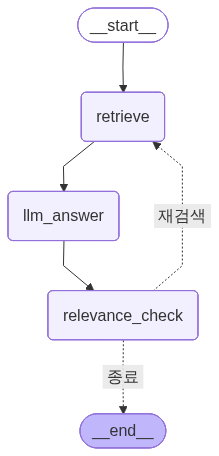

In [24]:
# 그래프 흐름: START → retrieve → llm_answer → relevance_check → (END | retrieve)
# retrieve: 벡터 검색 수행 + 재시도 횟수를 추적해요
# llm_answer: RAG 체인으로 답변을 생성해요
# relevance_check: LLM으로 검색 문서의 관련성을 yes/no로 판단해요
# 조건부 엣지: 관련성 있으면 END, 없고 재시도 가능하면 retrieve로 루프해요
# 재검색 루프 그래프 시각화 (루프가 보여야 해요!)
from IPython.display import Image, display
display(Image(rag_with_loop.get_graph().draw_mermaid_png()))

In [25]:
# ---------------------------------------------------
# 재검색 루프 RAG 실행
# ---------------------------------------------------
thread_id2 = str(uuid.uuid4())  # 새로운 대화 세션

config2 = RunnableConfig(
    recursion_limit=20,   # 재검색 루프 최대 20번
    configurable={"thread_id": thread_id2},
)

inputs2 = {
    "question": "삼성전자가 개발한 생성형 AI의 이름은 무엇인가요?",
    "context": "",
    "answer": "",
    "messages": [],
    "binary_score": "",
    "retry_count": 0,  # 재시도 횟수 초기화
}

print(f"질문: {inputs2['question']}")
# ==================================================

# 스트리밍 실행으로 각 노드 출력 확인
for chunk in rag_with_loop.stream(inputs2, config2, stream_mode="updates"):
    for node_name, node_output in chunk.items():
        print(f"\n--- 노드: {node_name} ---")
        if node_name == "retrieve":
            context_len = len(node_output.get("context", ""))
            print(f"검색 완료: 컨텍스트 {context_len}자")
        elif node_name == "llm_answer":
            print(f"답변: {node_output.get('answer', '')[:200]}...")
        elif node_name == "relevance_check":
            score = node_output.get("binary_score", "")
            print(f"관련성 판단: {score}")

질문: 삼성전자가 개발한 생성형 AI의 이름은 무엇인가요?

--- 노드: retrieve ---
검색 완료: 컨텍스트 3000자

--- 노드: llm_answer ---
답변: 삼성전자가 개발한 생성형 AI의 이름은 '삼성 가우스'입니다. 출처: 삼성전자, ‘삼성 AI 포럼’서 자체 개발 생성형 AI ‘삼성 가우스’ 공개, 2023.11.08. 페이지 13....
  [관련성 판단] yes (원본: yes)

--- 노드: relevance_check ---
관련성 판단: yes


## 8. 실습: 나만의 RAG 파이프라인 커스터마이징

아래 실습 해설 블록을 수정해서 다양한 설정을 실험해봐요.

In [26]:
# ============================================================
# 실습 해설: 아래 파라미터를 변경해서 RAG 성능 차이를 실험해보세요
#
# 실험 1: Retriever의 k값 변경
#   - k=2 vs k=4 vs k=8: 검색 문서 수를 변경해요
#   - 너무 작으면 관련 문서를 놓치고, 너무 크면 노이즈가 증가해요
#
# 힌트: vectorstore.as_retriever(search_kwargs={"k": ??})
#
# 실험 2: 다른 질문으로 테스트
#   - "삼성전자의 AI 관련 발표 내용은?"
#   - "EU AI 법안의 주요 내용은?"
#
# 예상 결과: k를 늘리면 더 많은 문서를 참고하지만 처리 시간이 늘어나요
# ============================================================

# k 값을 변경해보세요
k_value = 4  # 실습 해설: 2, 4, 8 등으로 변경해서 차이를 확인하세요

# 새 Retriever 생성
custom_retriever = vectorstore.as_retriever(search_kwargs={"k": k_value})

# 질문을 변경해보세요
test_question = "삼성전자가 공개한 생성 AI의 이름은 무엇인가요?"  # 실습 해설: 다른 질문으로 바꿔보세요

# 실험 실행
test_results = custom_retriever.invoke(test_question)

print(f"실험 설정: k={k_value}")
print(f"질문: {test_question}")
print(f"검색 결과: {len(test_results)}개 문서")
print()

for i, doc in enumerate(test_results):
    print(f"[{i+1}] {doc.page_content[:150]}...")
    print()

실험 설정: k=4
질문: 삼성전자가 공개한 생성 AI의 이름은 무엇인가요?
검색 결과: 4개 문서

[1] KEY Contents
£언어, 코드, 이미지의 3개 모델로 구성된 삼성 가우스, 온디바이스 작동 지원n삼성전자가 2023년 11월 8일 열린 ‘삼성 AI 포럼 2023’ 행사에서 자체 개발한 생성 AI 모델 ‘삼성 가우스’를 최초 공개∙정규분포 이론을 정립한 천재 수...

[2] SPRi AI Brief |  2023-12월호
10
삼성전자, 자체 개발 생성 AI ‘삼성 가우스’ 공개n삼성전자가 온디바이스에서 작동 가능하며 언어, 코드, 이미지의 3개 모델로 구성된 자체 개발 생성 AI 모델 ‘삼성 가우스’를 공개n삼성전자는 삼성 가우스를 다양...

[3] Ⅰ. 인공지능 산업 동향 브리프 1. 정책/법제    ▹ 미국, 안전하고 신뢰할 수 있는 AI 개발과 사용에 관한 행정명령 발표  ·························1   ▹ G7, 히로시마 AI 프로세스를 통해 AI 기업 대상 국제 행동강령에 합의·····...

[4] 분류했으며, 특수 AI에서는 5단계까지 달성되었으나, 범용 AI는 현재 1단계 수준성능 특수 AI 예시범용 AI 예시0단계: AI 아님계산기 소프트웨어, 컴파일러아마존 메커니컬 터크1단계: 신진(숙련되지 않은 인간)GOFAI(Good Old Fashioned Artif...



## 9. 주요 패턴 비교

이 노트북에서 구현한 두 가지 RAG 패턴을 비교해볼게요.

| 패턴 | 그래프 구조 | 장점 | 단점 |
|------|-----------|------|------|
| **Naive RAG** | retrieve → llm_answer | 단순, 빠름 | 관련성 미검증 |
| **재검색 루프** | retrieve → llm_answer → relevance_check → (루프) | 품질 보장 | LLM 호출 추가 |

> 🎯 **강의 포인트**: 재검색 루프는 관련성 판단에 LLM을 한 번 더 호출해요. "비용 vs 품질" 트레이드오프를 설명해 주세요. 실무에서는 빠른 임베딩 기반 코사인 유사도 점수가 0.7 미만일 때만 재검색하는 방식을 많이 사용해요.

> 💡 **실무 팁**: LangSmith 추적을 활성화했다면 각 노드의 실행 시간과 LLM 토큰 사용량을 확인할 수 있어요. 재검색 루프가 평균 몇 번 발생하는지 분석하면 파이프라인을 최적화할 수 있어요.

## RAG 시스템의 흔한 함정들

RAG 시스템을 처음 구축할 때 자주 빠지는 함정들을 정리했어요.

> ⚠️ **자주 하는 실수**: 아래 5가지는 RAG 프로젝트에서 가장 빈번한 실수예요.

| 함정 | 증상 | 해결 방법 |
|------|------|----------|
| **청크가 너무 큼** | 답변에 관련 없는 내용이 많음 | `chunk_size`를 500~1000자로 줄이세요 |
| **청크가 너무 작음** | 핵심 문맥이 잘림 | `chunk_overlap`을 200자 이상으로 늘리세요 |
| **검색 결과 미검증** | 환각(Hallucination) 발생 | Groundedness Check 노드를 추가하세요 |
| **임베딩 캐시 미사용** | API 비용 급증 | `CacheBackedEmbeddings`로 캐시하세요 |
| **프롬프트에 출처 미포함** | 답변 신뢰도 저하 | XML 태그로 출처를 프롬프트에 포함하세요 |

> 💡 **실무 팁**: 첫 번째 RAG 시스템은 Naive RAG로 만들고, LangSmith로 검색 품질을 모니터링하면서 점진적으로 개선하는 것이 가장 효과적이에요. 처음부터 Adaptive RAG를 적용하면 디버깅이 어려워져요.

## 핵심 요약

이 노트북에서 다음 내용을 배웠어요:

- **Naive RAG**: `retrieve → llm_answer` 2단계 파이프라인. 단순하지만 관련성 미검증이라는 한계가 있어요
- **format_docs**: `Document` 리스트를 XML 태그로 변환하여 LLM이 문서 경계를 명확히 인식하게 해요. 간접 프롬프트 인젝션도 방어해요
- **GraphState**: `question`, `context`, `answer`, `messages` 필드로 RAG 파이프라인 상태를 관리해요. `messages`는 `add_messages` 리듀서로 누적돼요
- **MemorySaver + thread_id**: 대화 세션별로 상태를 저장하여 멀티턴 대화를 지원해요
- **add_conditional_edges**: 관련성 판단 결과에 따라 재검색 또는 종료를 결정하는 루프를 만들 수 있어요
- **노드 분리**: 검색(retrieve)과 생성(llm_answer)을 독립 노드로 분리하면 각각 교체·테스트가 쉬워요

## 다음 노트북 예고

### Part 08 전체 로드맵

이 노트북에서 **Naive RAG**의 기본기를 다졌어요. Part 08에서는 점진적으로 더 강력한 RAG 시스템을 만들어가요:

| 노트북 | 핵심 질문 | 추가되는 기능 |
|--------|----------|-------------|
| **01 (현재)** | "문서에서 찾아줘" | Retrieve → Generate 기본 파이프라인 |
| **02 Agentic** | "검색할지 말지 알아서 판단해" | 에이전트 자율 도구 선택 + Groundedness |
| **03 CRAG/Self** | "답변이 정말 맞는지 검증해" | 환각 검증 + 자기 교정 루프 |
| **04 Adaptive** | "어디서 검색할지 먼저 결정해" | 질문 라우팅 + 3단계 검증 |
| **05 Retrieval** | "검색 자체를 더 똑똑하게" | 쿼리 강화 + MMR + 메타데이터 필터링 |

다음 `02-Agentic-RAG.ipynb`에서는 **에이전트 기반 RAG(Agentic RAG)**를 배워요. 단순한 검색 루프를 넘어, 에이전트가 자율적으로 검색 전략을 결정하고 Groundedness Check(근거 기반 판단)와 웹 검색을 결합하는 더 강력한 RAG 시스템을 구현해요.